# Limpieza de datos y construcción de la matriz A

Este notebook prepara los datos para el modelo de programación lineal de mezclas de aceites esenciales.

**Artefactos que produce:**
- `data/matrix_A.csv` — Matriz A (aceites × compuestos), parámetros a_ij del modelo PL
- `data/eo_aggregated.csv` — Tabla larga con media/std/n por (especie, compuesto)
- `data/prices_clean.csv` — Precios doTERRA con precio_por_mL calculado
- `data/therapy_clean.csv` — Usos terapéuticos filtrados a aceites disponibles en doTERRA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 50)

RAW   = Path("data/raw")
CLEAN = Path("data/clean")
CLEAN.mkdir(parents=True, exist_ok=True)

## Sección 1 — Carga y exploración inicial

In [ ]:
eo      = pd.read_csv(RAW / "essential_oil_scentindb.csv", sep="\t", low_memory=False)
chem    = pd.read_csv(RAW / "chemical_scentindb.csv",    sep="\t", low_memory=False)
therapy = pd.read_csv(RAW / "therapy_scentindb.csv",     sep="\t", low_memory=False)
prices  = pd.read_excel(RAW / "lista de precios doterra.xlsx")

print(f"essential_oil:  {eo.shape}")
print(f"chemical:       {chem.shape}")
print(f"therapy:        {therapy.shape}")
print(f"prices:         {prices.shape}")

In [3]:
print("=== essential_oil_scentindb.csv ===")
print(eo.dtypes)
print("\nNulos por columna:")
print(eo.isnull().sum()[eo.isnull().sum() > 0])

=== essential_oil_scentindb.csv ===
Sno                        int64
ESO Number                object
Plant name                object
Plant Part                object
Plant Subpart             object
Geographical location     object
Analysis_method           object
Column                    object
Isolation_method          object
RI (Retention Index)     float64
RT (Retention Time)      float64
EOCID                     object
Chemical Name             object
Percentage               float64
Reference                 object
dtype: object

Nulos por columna:
Plant Part                654
Plant Subpart             654
Analysis_method           451
Column                    759
Isolation_method         8492
RI (Retention Index)    13096
RT (Retention Time)     79159
EOCID                    1009
dtype: int64


In [4]:
print("=== Distribución de filas por Plant name (top 20) ===")
print(eo["Plant name"].value_counts().head(20))

=== Distribución de filas por Plant name (top 20) ===
Plant name
Ocimum basilicum            2961
Piper nigrum                2714
Juglans regia               1960
Zingiber officinale         1876
Ocimum americanum           1606
Cymbopogon martini          1579
Pelargonium graveolens      1388
Acorus calamus              1358
Ocimum kilimandscharicum    1310
Coriandrum sativum          1159
Zingiber zerumbet           1147
Jasminum sambac             1131
Cinnamomum tamala           1056
Mentha arvensis             1024
Alpinia calcarata           1001
Valeriana jatamansi          959
Cymbopogon flexuosus         958
Ocimum tenuiflorum           935
Artemisia annua              922
Kaempferia galanga           852
Name: count, dtype: int64


In [5]:
print("=== Productos doTERRA (80 aceites) ===")
print(prices[["ACEITES", "mL", "Costo Inscritos", "Costo Retail"]].to_string(index=False))

=== Productos doTERRA (80 aceites) ===
                      ACEITES    mL  Costo Inscritos  Costo Retail
                       Abedul   5.0             1205          1607
                  Abeto Negro   5.0              502           669
              Abeto Siberiano  15.0              502           669
                        Abode  15.0              610           813
                     Albahaca  15.0              495           660
                  Árbol de Té  15.0              495           660
Arborvitae (Árbol de la vida)   5.0              534           712
               Baya de Enebro   5.0              502           669
                    Bergamota  15.0              654           872
      Blue Tansy (Tansy Azul)   5.0             1885          2514
                        Limón  15.0              244           325
                      Cananga  15.0              985          1313
                       Canela   5.0              508           677
                    Car

In [6]:
print("=== Usos terapéuticos únicos en therapy_scentindb ===")
print(therapy["Therapeutic use"].value_counts().to_string())

=== Usos terapéuticos únicos en therapy_scentindb ===
Therapeutic use
Anti-Bacterial Agents                                          164
Antifungal Agents                                              117
antioxidant activity                                            77
Antimicrobial activity function                                 41
Anti-Inflammatory Agents                                        27
Antihelmintics                                                  13
Antinematodal Agents                                             9
Anticancer agents                                                8
Cytotoxin                                                        7
Analgesics                                                       5
Fungicide                                                        4
Fungistat                                                        4
Tranquilizing Agents                                             4
Antipyretics                                               

## Sección 2 — Mapeo: nombres doTERRA → especie botánica

Construimos el diccionario manualmente. Los nombres del Excel están en español; la BD usa nombres científicos en latín.  
Se incluyen todos los aceites puros (no mezclas) del catálogo doTERRA que tienen match en la BD.

In [7]:
# Mapeo nombre doTERRA (español, exactamente como aparece en el Excel) → especie botánica en la BD
# Nota: "Eucalipto" no está en el catálogo doTERRA México como aceite individual.
# "Eucalipto Limón" = Corymbia citriodora (antes Eucalyptus citriodora).
# "Canela" mapea a Cinnamomum verum (sinónimo de C. zeylanicum, que es como está en la BD).
DOTERRA_TO_BOTANICAL = {
    "Árbol de Té":                   "Melaleuca alternifolia",
    "Lavanda":                        "Lavandula angustifolia",
    "Limón":                          "Citrus limon",
    "Menta":                          "Mentha piperita",
    "Romero":                         "Rosmarinus officinalis",
    "Eucalipto Limón":                "Corymbia citriodora",
    "Incienso":                       "Boswellia serrata",
    "Cilantro":                       "Coriandrum sativum",
    "Limoncillo":                     "Cymbopogon flexuosus",
    "Citronela":                      "Cymbopogon nardus",
    "Cardamomo":                      "Elettaria cardamomum",
    "Hinojo":                         "Foeniculum vulgare",
    "Baya de Enebro":                 "Juniperus communis",
    "Hierbabuena":                    "Mentha spicata",
    "Nardo":                          "Nardostachys jatamansi",
    "Albahaca":                       "Ocimum basilicum",
    "Tulsi":                          "Ocimum tenuiflorum",
    "Mejorana":                       "Origanum majorana",
    "Orégano":                        "Origanum vulgare",
    "Geranio":                        "Pelargonium graveolens",
    "Pimienta Negra":                 "Piper nigrum",
    "Pachulí":                        "Pogostemon cablin",
    "Salvia":                         "Salvia officinalis",
    "Sándalo":                        "Santalum album",
    "Clavo":                          "Syzygium aromaticum",
    "Tomillo":                        "Thymus vulgaris",
    "Jengibre":                       "Zingiber officinale",
    "Petitgrain":                     "Citrus aurantium",
    "Cananga":                        "Cananga odorata",
    "Ylang Ylang":                    "Cananga odorata",
    "Canela":                         "Cinnamomum verum",
}

BOTANICAL_TO_DOTERRA = {v: k for k, v in DOTERRA_TO_BOTANICAL.items()}

print(f"Aceites en el mapeo: {len(DOTERRA_TO_BOTANICAL)}")
print(f"Especies únicas (algunas comparten especie): {len(set(DOTERRA_TO_BOTANICAL.values()))}")

Aceites en el mapeo: 31
Especies únicas (algunas comparten especie): 30


In [8]:
# Verificar qué aceites del mapeo tienen filas en la BD
botanical_in_bd = set(eo["Plant name"].unique())
botanical_mapped = set(DOTERRA_TO_BOTANICAL.values())

match    = botanical_mapped & botanical_in_bd
no_match = botanical_mapped - botanical_in_bd

print(f"Con match en BD:    {len(match)}")
print(f"Sin match en BD:    {len(no_match)}")
print("\n-- Sin match (quedan fuera de A) --")
for sp in sorted(no_match):
    doterra = BOTANICAL_TO_DOTERRA.get(sp, "?")
    print(f"  {doterra:30s} → {sp}")

print("\n-- Con match --")
for sp in sorted(match):
    n = (eo["Plant name"] == sp).sum()
    doterra = BOTANICAL_TO_DOTERRA.get(sp, "?")
    print(f"  {doterra:30s} → {sp}  ({n} filas)")

Con match en BD:    30
Sin match en BD:    0

-- Sin match (quedan fuera de A) --

-- Con match --
  Incienso                       → Boswellia serrata  (168 filas)
  Ylang Ylang                    → Cananga odorata  (25 filas)
  Canela                         → Cinnamomum verum  (725 filas)
  Petitgrain                     → Citrus aurantium  (101 filas)
  Limón                          → Citrus limon  (83 filas)
  Cilantro                       → Coriandrum sativum  (1159 filas)
  Eucalipto Limón                → Corymbia citriodora  (569 filas)
  Limoncillo                     → Cymbopogon flexuosus  (958 filas)
  Citronela                      → Cymbopogon nardus  (52 filas)
  Cardamomo                      → Elettaria cardamomum  (118 filas)
  Hinojo                         → Foeniculum vulgare  (10 filas)
  Baya de Enebro                 → Juniperus communis  (27 filas)
  Lavanda                        → Lavandula angustifolia  (414 filas)
  Árbol de Té                    → Melal

In [9]:
# Calcular precio por mL para cada aceite con match
prices_clean = prices[prices["ACEITES"].isin(DOTERRA_TO_BOTANICAL.keys())].copy()
prices_clean["precio_por_mL"] = prices_clean["Costo Inscritos"] / prices_clean["mL"]
prices_clean = prices_clean.sort_values("precio_por_mL", ascending=False)

print("Aceites doTERRA ordenados por precio/mL (Costo Inscritos):")
print(prices_clean[["ACEITES", "mL", "Costo Inscritos", "precio_por_mL"]].to_string(index=False))

Aceites doTERRA ordenados por precio/mL (Costo Inscritos):
        ACEITES   mL  Costo Inscritos  precio_por_mL
        Sándalo  5.0             1652     330.400000
          Nardo  5.0             1184     236.800000
      Cardamomo  5.0              702     140.400000
          Tulsi  5.0              660     132.000000
       Incienso 15.0             1650     110.000000
 Pimienta Negra  5.0              520     104.000000
         Canela  5.0              508     101.600000
 Baya de Enebro  5.0              502     100.400000
        Cananga 15.0              985      65.666667
         Salvia 15.0              892      59.466667
    Ylang Ylang 15.0              842      56.133333
    Hierbabuena 15.0              705      47.000000
       Jengibre 15.0              696      46.400000
        Pachulí 15.0              665      44.333333
        Tomillo 15.0              654      43.600000
        Geranio 15.0              648      43.200000
     Petitgrain 15.0              632   

## Sección 3 — Filtrar BD y normalizar nombres de compuestos

In [10]:
# Filtrar a solo los aceites con match en la BD
species_with_match = sorted(match)
eo_f = eo[eo["Plant name"].isin(species_with_match)].copy()
print(f"Filas tras filtrar por especie: {len(eo_f):,}  (de {len(eo):,})")
print(f"Especies: {eo_f['Plant name'].nunique()}")

# Vista previa de Plant Parts disponibles por especie
print("\n=== Plant Part por especie (todas las partes presentes) ===")
for sp in sorted(species_with_match):
    parts = eo_f[eo_f["Plant name"] == sp]["Plant Part"].value_counts()
    doterra = BOTANICAL_TO_DOTERRA.get(sp, sp)
    print(f"\n{doterra} ({sp}):")
    print(parts.to_string())

Filas tras filtrar por especie: 17,852  (de 85,341)
Especies: 30

=== Plant Part por especie (todas las partes presentes) ===

Incienso (Boswellia serrata):
Plant Part
plant exudate    168

Ylang Ylang (Cananga odorata):
Plant Part
leaf    25

Canela (Cinnamomum verum):
Plant Part
leaf     645
fruit     64
bark      16

Petitgrain (Citrus aurantium):
Plant Part
fruit    74

Limón (Citrus limon):
Plant Part
fruit    48
leaf     35

Cilantro (Coriandrum sativum):
Plant Part
leaf           497
whole plant    312
seed           200
flower         150

Eucalipto Limón (Corymbia citriodora):
Plant Part
leaf      386
flower     91
fruit      88

Limoncillo (Cymbopogon flexuosus):
Plant Part
aerial part    618
seed           246
leaf            83
flower           9

Citronela (Cymbopogon nardus):
Plant Part
whole plant    52

Cardamomo (Elettaria cardamomum):
Plant Part
fruit    118

Hinojo (Foeniculum vulgare):
Plant Part
seed    10

Baya de Enebro (Juniperus communis):
Plant Part
leaf    27

In [11]:
PART_OVERRIDE = {
    "Boswellia serrata":      "resin",
    "Citrus limon":           "peel",
    "Citrus aurantium":       "leaf",   # petitgrain es de hoja, no fruta
}

def apply_part_filter(df, part_override):
    rows = []
    for sp, grp in df.groupby("Plant name"):
        if sp in part_override:
            target = part_override[sp]
            filtered = grp[grp["Plant Part"] == target]
        else:
            counts = grp["Plant Part"].value_counts()
            if len(counts) == 0:
                rows.append(grp)
                continue
            target = counts.index[0]
            filtered = grp[grp["Plant Part"] == target]
        rows.append(filtered if len(filtered) > 0 else grp)
    return pd.concat(rows, ignore_index=True)

eo_f = apply_part_filter(eo_f, PART_OVERRIDE)
print(f"Filas tras filtrar por Plant Part: {len(eo_f):,}")
print("\nFilas y Plant Part elegido por especie:")
for sp in sorted(eo_f["Plant name"].unique()):
    part = eo_f[eo_f["Plant name"] == sp]["Plant Part"].dropna()
    part_name = part.iloc[0] if len(part) > 0 else "N/A"
    n = (eo_f["Plant name"] == sp).sum()
    doterra = BOTANICAL_TO_DOTERRA.get(sp, sp)
    print(f"  {doterra:25s}  {part_name:20s}  ({n} filas)")

Filas tras filtrar por Plant Part: 13,259

Filas y Plant Part elegido por especie:
  Incienso                   plant exudate         (168 filas)
  Ylang Ylang                leaf                  (25 filas)
  Canela                     leaf                  (645 filas)
  Petitgrain                 fruit                 (101 filas)
  Limón                      fruit                 (83 filas)
  Cilantro                   leaf                  (497 filas)
  Eucalipto Limón            leaf                  (386 filas)
  Limoncillo                 aerial part           (618 filas)
  Citronela                  whole plant           (52 filas)
  Cardamomo                  fruit                 (118 filas)
  Hinojo                     seed                  (10 filas)
  Baya de Enebro             leaf                  (27 filas)
  Lavanda                    flower                (414 filas)
  Árbol de Té                leaf                  (26 filas)
  Menta                      aerial part 

In [12]:
# Normalizar nombre de compuesto via join con chemical_scentindb por EOCID
# chemical_scentindb tiene "Chemical_name" como nombre canónico normalizado
chem_dict = chem[["EOCID", "Chemical_name"]].drop_duplicates("EOCID")

eo_f = eo_f.merge(chem_dict, on="EOCID", how="left")
eo_f["chem_final"] = (
    eo_f["Chemical_name"]
    .fillna(eo_f["Chemical Name"])
    .str.strip()
)

print(f"Compuestos únicos (nombre canónico): {eo_f['chem_final'].nunique()}")
print(f"Filas con nombre canónico del dict: {eo_f['Chemical_name'].notna().sum():,}")
print(f"Filas con nombre original (fallback): {eo_f['Chemical_name'].isna().sum():,}")

Compuestos únicos (nombre canónico): 617
Filas con nombre canónico del dict: 13,185
Filas con nombre original (fallback): 74


## Sección 4 — Agregación: promedio por (especie, compuesto)

In [13]:
df_agg = (
    eo_f
    .dropna(subset=["Percentage"])
    .groupby(["Plant name", "chem_final"])["Percentage"]
    .agg(n_samples="count", pct_mean="mean", pct_std="std")
    .reset_index()
)

print(f"Filas en tabla agregada: {len(df_agg):,}")
print(f"Especie-compuesto únicos: {len(df_agg):,}")
print(f"\nDistribución de n_samples (cuántas mediciones se promediaron):")
print(df_agg["n_samples"].describe().round(1))

Filas en tabla agregada: 1,807
Especie-compuesto únicos: 1,807

Distribución de n_samples (cuántas mediciones se promediaron):
count    1807.0
mean        7.3
std        11.4
min         1.0
25%         1.0
50%         2.0
75%         9.0
max        88.0
Name: n_samples, dtype: float64


In [14]:
# Compuestos dominantes por especie (top 5)
print("=== Top 5 compuestos por especie ===")
for sp in sorted(df_agg["Plant name"].unique()):
    top = (
        df_agg[df_agg["Plant name"] == sp]
        .nlargest(5, "pct_mean")[["chem_final", "pct_mean", "n_samples"]]
    )
    doterra = BOTANICAL_TO_DOTERRA.get(sp, sp)
    print(f"\n{doterra} ({sp}):")
    for _, r in top.iterrows():
        print(f"  {r['chem_final']:45s}  {r['pct_mean']:6.1f}%  (n={int(r['n_samples'])})")

=== Top 5 compuestos por especie ===

Incienso (Boswellia serrata):
  Bicyclo[3.1.0]hex-2-ene, 2-methyl-5-(1-methylethyl)-    37.4%  (n=5)
  3,7-Dimethyloctan-3-ol                            8.6%  (n=4)
  (+)-3-Carene                                      6.0%  (n=5)
  epi-Cubenol                                       5.5%  (n=4)
  Limonene, (-)-                                    3.9%  (n=5)

Ylang Ylang (Cananga odorata):
  Caryophyllene                                    19.7%  (n=1)
  beta-OCIMENE, (3E)-                              13.2%  (n=1)
  Alpha-Farnesene                                  10.3%  (n=1)
  Phenylmethyl ester                                5.6%  (n=1)
  Farnesylacetone                                   5.1%  (n=1)

Canela (Cinnamomum verum):
  Eugenol                                          79.9%  (n=15)
  Eugenol acetate                                   5.2%  (n=15)
  Benzyl Benzoate                                   2.7%  (n=14)
  Linalool, (+/-)-            

## Sección 5 — Construcción de la matriz A

In [15]:
A = df_agg.pivot_table(
    index="Plant name",
    columns="chem_final",
    values="pct_mean",
    fill_value=0.0
)

# Renombrar filas a nombre doTERRA para legibilidad
A.index = A.index.map(lambda sp: BOTANICAL_TO_DOTERRA.get(sp, sp))
A.columns.name = None

print(f"Dimensiones de A: {A.shape}  ({A.shape[0]} aceites × {A.shape[1]} compuestos)")
print(f"\nSuma de filas (% total detectado por GC-MS):")
print(A.sum(axis=1).round(1).to_string())

Dimensiones de A: (30, 617)  (30 aceites × 617 compuestos)

Suma de filas (% total detectado por GC-MS):
Plant name
Incienso            96.8
Ylang Ylang         88.2
Canela             105.6
Petitgrain         189.5
Limón              108.4
Cilantro           138.9
Eucalipto Limón    144.6
Limoncillo         101.4
Citronela          109.0
Cardamomo          132.7
Hinojo             160.5
Baya de Enebro      89.4
Lavanda             92.8
Árbol de Té         94.6
Menta               83.4
Hierbabuena        110.5
Nardo               74.8
Albahaca           178.5
Tulsi              119.0
Mejorana            96.8
Orégano             97.7
Geranio             88.1
Pimienta Negra      95.4
Pachulí             88.6
Romero              97.4
Salvia              97.5
Sándalo             88.5
Clavo              104.2
Tomillo             98.2
Jengibre           164.9


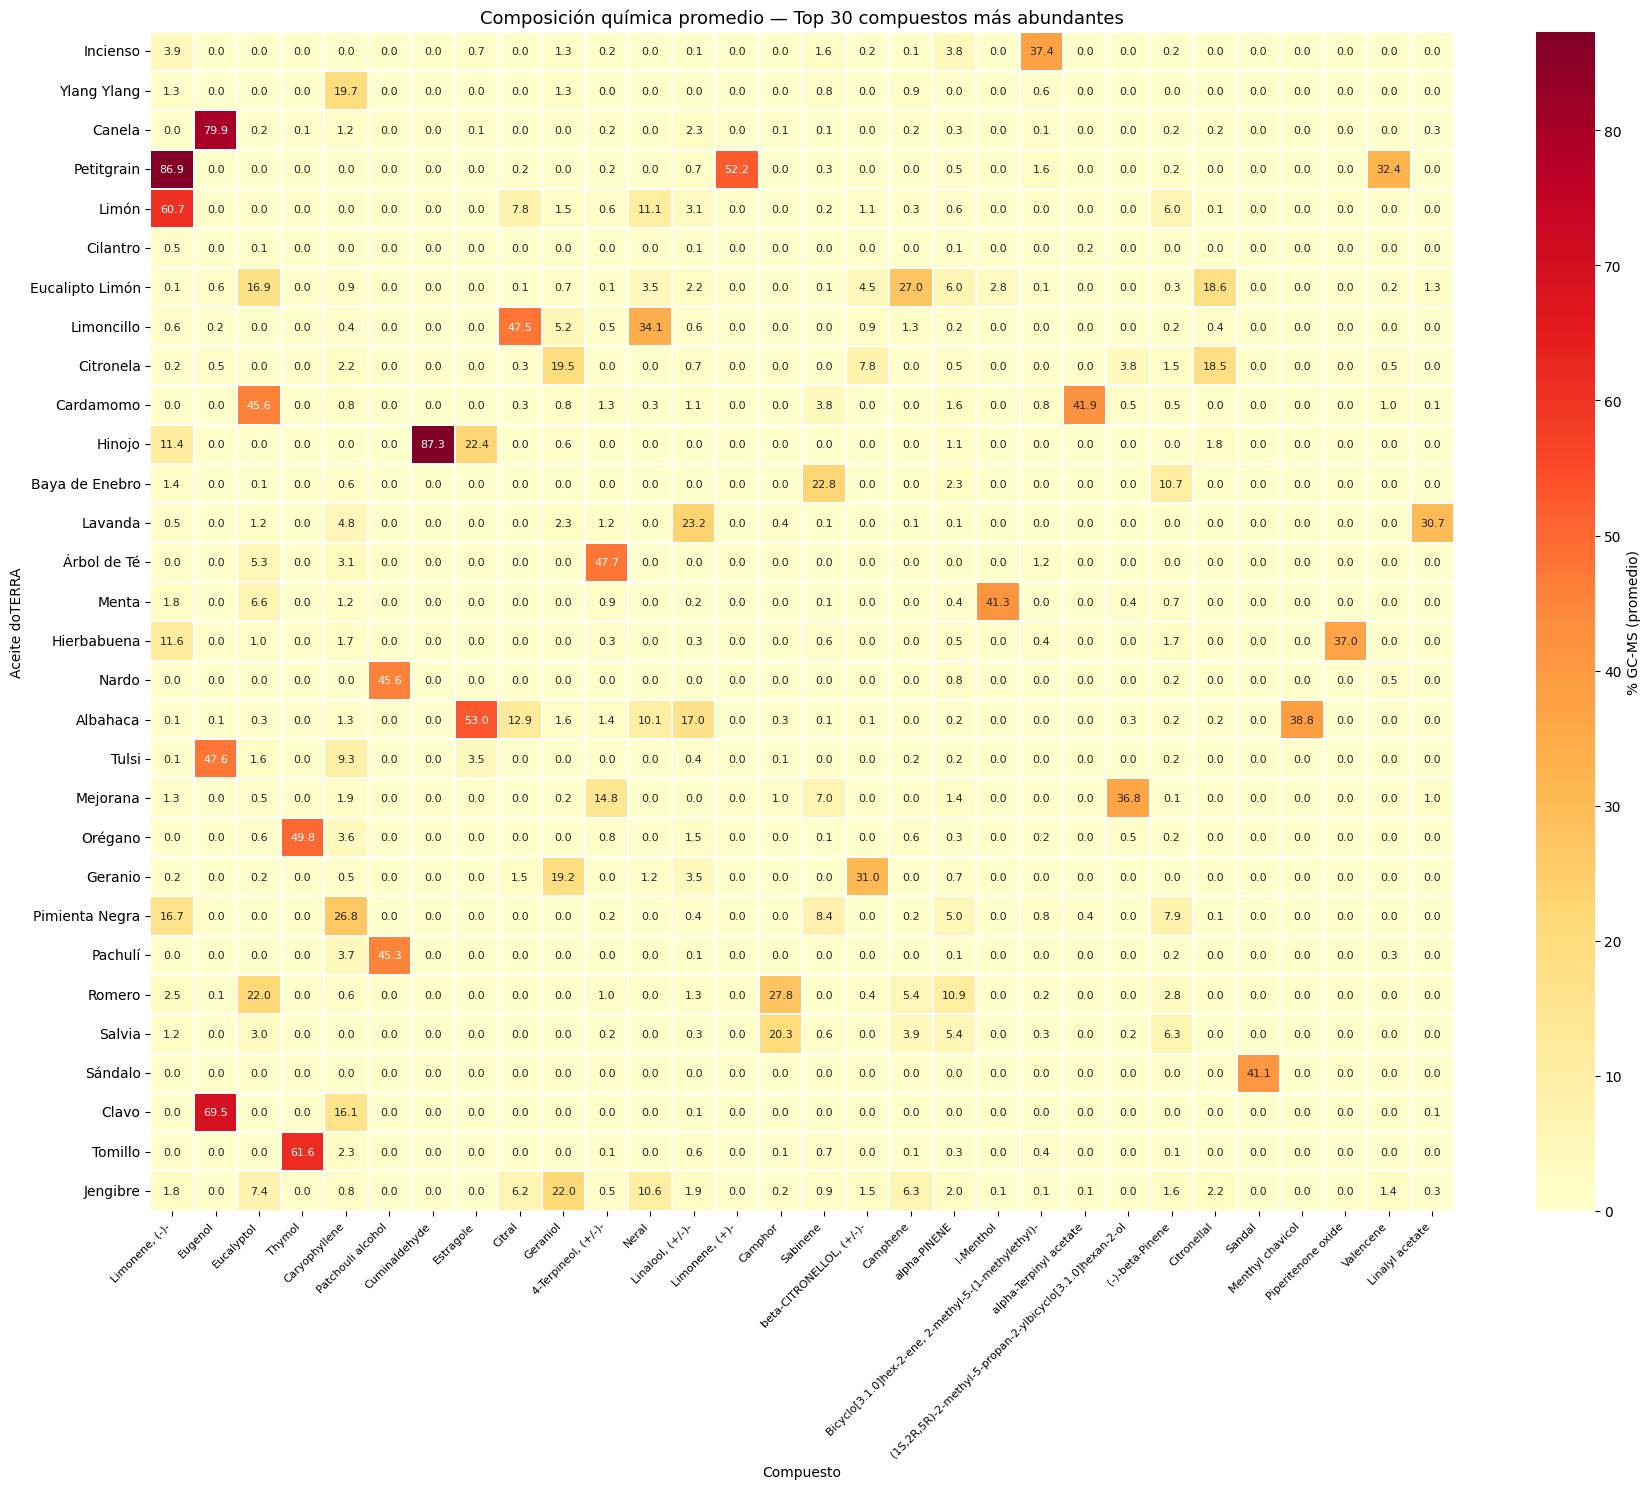

In [16]:
# Heatmap de los 30 compuestos más abundantes en promedio global
top30 = A.mean(axis=0).nlargest(30).index
A_top30 = A[top30]

fig, ax = plt.subplots(figsize=(18, max(5, len(A) * 0.5)))
sns.heatmap(
    A_top30,
    annot=True, fmt=".1f", annot_kws={"size": 8},
    cmap="YlOrRd", linewidths=0.3,
    cbar_kws={"label": "% GC-MS (promedio)"},
    ax=ax
)
ax.set_title("Composición química promedio — Top 30 compuestos más abundantes", fontsize=13)
ax.set_xlabel("Compuesto")
ax.set_ylabel("Aceite doTERRA")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

## Sección 6 — Datos de terapia para escenarios dinámicos

Los escenarios de optimización no están fijos de antemano. Se generan a partir de los usos terapéuticos reportados en `therapy_scentindb.csv`. Dado un uso terapéutico, identificamos qué plantas están asociadas → qué compuestos son activos → construimos el vector **c** de pesos para el modelo PL.

In [17]:
print(f"Usos terapéuticos únicos: {therapy['Therapeutic use'].nunique()}")
print(f"Plantas únicas en therapy: {therapy['Plant name'].nunique()}")

# Cuántas plantas de therapy están en nuestro catálogo doTERRA
therapy_in_doterra = therapy["Plant name"].isin(DOTERRA_TO_BOTANICAL.values())
print(f"\nRegistros de therapy con planta en doTERRA: {therapy_in_doterra.sum()} de {len(therapy)}")

therapy_doterra = therapy[therapy_in_doterra].copy()
therapy_doterra["aceite_doterra"] = therapy_doterra["Plant name"].map(BOTANICAL_TO_DOTERRA)

print("\nUsos terapéuticos cubiertos por aceites doTERRA:")
print(therapy_doterra["Therapeutic use"].value_counts().to_string())

Usos terapéuticos únicos: 41
Plantas únicas en therapy: 209

Registros de therapy con planta en doTERRA: 54 de 515

Usos terapéuticos cubiertos por aceites doTERRA:
Therapeutic use
Anti-Bacterial Agents                    17
Antifungal Agents                        17
antioxidant activity                      7
Antimicrobial activity function           3
Cytotoxin                                 2
Anti-Inflammatory Agents                  2
Anticancer agents                         1
Antihelmintics                            1
Fungistat                                 1
Fungicide                                 1
Anxiolytics [TC-therapeutic category]     1
ovicidal activity                         1


In [18]:
# Mapa uso terapéutico → lista de aceites doTERRA disponibles
therapy_map = (
    therapy_doterra
    .groupby("Therapeutic use")["aceite_doterra"]
    .apply(lambda x: sorted(x.unique().tolist()))
    .reset_index()
    .rename(columns={"aceite_doterra": "aceites_doterra"})
)
therapy_map["n_aceites"] = therapy_map["aceites_doterra"].apply(len)
therapy_map = therapy_map.sort_values("n_aceites", ascending=False)

print("Usos terapéuticos con más aceites doTERRA disponibles:")
for _, row in therapy_map.head(15).iterrows():
    print(f"\n  [{row['n_aceites']} aceites] {row['Therapeutic use']}")
    print(f"    {', '.join(row['aceites_doterra'])}")

Usos terapéuticos con más aceites doTERRA disponibles:

  [13 aceites] Antifungal Agents
    Baya de Enebro, Canela, Cardamomo, Cilantro, Eucalipto Limón, Geranio, Hinojo, Incienso, Jengibre, Limoncillo, Limón, Orégano, Petitgrain

  [12 aceites] Anti-Bacterial Agents
    Canela, Cardamomo, Cilantro, Eucalipto Limón, Hinojo, Incienso, Lavanda, Limón, Orégano, Petitgrain, Romero, Salvia

  [6 aceites] antioxidant activity
    Canela, Cilantro, Clavo, Jengibre, Orégano, Ylang Ylang

  [3 aceites] Antimicrobial activity function
    Canela, Clavo, Hinojo

  [2 aceites] Cytotoxin
    Eucalipto Limón, Tulsi

  [2 aceites] Anti-Inflammatory Agents
    Geranio, Limón

  [1 aceites] Anticancer agents
    Ylang Ylang

  [1 aceites] Antihelmintics
    Incienso

  [1 aceites] Anxiolytics [TC-therapeutic category]
    Lavanda

  [1 aceites] Fungicide
    Baya de Enebro

  [1 aceites] Fungistat
    Baya de Enebro

  [1 aceites] ovicidal activity
    Canela


## Sección 7 — Verificación de valores clave

Checklist que confirma que los datos son razonables antes de exportar.

In [19]:
def check(label, condition, value, expected):
    status = "OK" if condition else "REVISAR"
    print(f"[{status}] {label}: {value:.1f}%  (esperado: {expected})")

def find_col(A, keywords):
    """Busca columna en A: primero match exacto, luego starts-with, luego substring más corta."""
    cols = A.columns
    for kw in keywords:
        for c in cols:
            if c.lower() == kw.lower():
                return c
    for kw in keywords:
        for c in cols:
            if c.lower().startswith(kw.lower()):
                return c
    candidates = [c for kw in keywords for c in cols if kw.lower() in c.lower()]
    return min(candidates, key=len) if candidates else None

print("=== Columnas encontradas para compuestos clave ===")
key_searches = {
    "linalyl acetate":  ["linalyl acetate", "linalool acetate"],
    "linalool":         ["Linalool, (+/-)"],
    "eucalyptol":       ["eucalyptol", "1,8-cineole"],
    "4-terpineol":      ["4-Terpineol", "terpinene-4-ol", "terpinen-4-ol"],
    "alpha-pinene":     ["alpha-PINENE", "alpha-pinene"],
    "limonene_pos":     ["Limonene, (+)"],
    "limonene_neg":     ["Limonene, (-)"],
    "menthol":          ["l-Menthol", "menthol"],
    "camphor":          ["camphor"],
    "caryophyllene":    ["caryophyllene"],
}
found = {}
for name, keywords in key_searches.items():
    col = find_col(A, keywords)
    found[name] = col
    print(f"  {name:20s} → {col}")

print()
print("=== Checks de valores esperados ===")
checks = [
    ("Lavanda",     "linalyl acetate", "linalyl acetate", 15, 60),
    ("Lavanda",     "linalool",        "linalool",         10, 40),
    ("Menta",       "menthol",         "menthol",          20, 60),
    ("Romero",      "camphor",         "camphor",          10, 40),
    ("Árbol de Té", "4-terpineol",     "4-terpineol",      30, 60),
    ("Limón",       "limonene (-)",    "limonene_neg",     30, 95),
]
for oil, name, key, lo, hi in checks:
    col = found.get(key)
    # buscar el aceite aunque tenga tilde (el índice usa el nombre doTERRA del Excel)
    oil_key = next((idx for idx in A.index if oil.lower() in idx.lower()), oil)
    if oil_key in A.index and col and col in A.columns:
        val = A.loc[oil_key, col]
        check(f"{oil_key} {name}", lo <= val <= hi, val, f"{lo}–{hi}%")
    else:
        print(f"[MISSING] {oil} {name}  (col={col}, aceite_en_A={oil_key in A.index})")

=== Columnas encontradas para compuestos clave ===
  linalyl acetate      → Linalyl acetate
  linalool             → Linalool, (+/-)-
  eucalyptol           → Eucalyptol
  4-terpineol          → 4-Terpineol, (+/-)-
  alpha-pinene         → alpha-PINENE
  limonene_pos         → Limonene, (+)-
  limonene_neg         → Limonene, (-)-
  menthol              → l-Menthol
  camphor              → Camphor
  caryophyllene        → Caryophyllene

=== Checks de valores esperados ===
[OK] Lavanda linalyl acetate: 30.7%  (esperado: 15–60%)
[OK] Lavanda linalool: 23.2%  (esperado: 10–40%)
[OK] Menta menthol: 41.3%  (esperado: 20–60%)
[OK] Romero camphor: 27.8%  (esperado: 10–40%)
[OK] Árbol de Té 4-terpineol: 47.7%  (esperado: 30–60%)
[OK] Limón limonene (-): 60.7%  (esperado: 30–95%)


## Sección 8 — Exportar artefactos limpios

In [ ]:
A.to_csv(CLEAN / "matrix_A.csv")
df_agg.to_csv(CLEAN / "eo_aggregated.csv", index=False)
prices_clean.to_csv(CLEAN / "prices_clean.csv", index=False)
therapy_doterra.to_csv(CLEAN / "therapy_clean.csv", index=False)

print("Artefactos exportados a data/clean/:")
for f in ["matrix_A.csv", "eo_aggregated.csv", "prices_clean.csv", "therapy_clean.csv"]:
    path = CLEAN / f
    size = path.stat().st_size / 1024
    print(f"  {f:30s}  {size:7.1f} KB")

print(f"\nResumen final:")
print(f"  Aceites en A:     {A.shape[0]}")
print(f"  Compuestos en A:  {A.shape[1]}")
print(f"  Escenarios terapéuticos disponibles:  {len(therapy_map)}")
print(f"  NaN en matrix_A:  {A.isnull().sum().sum()}")